## 1. Import Library dan Konfigurasi

In [24]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as stats

from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# =========================
# CONFIG
# =========================
FILE_PATH        = "AVG 12W & 5W.csv"   # CSV file — ubah sesuai nama file kamu

TEST_SIZE        = 5
FORECAST_HORIZON = 5
MIN_FAMILY_AVG   = 5

ARIMA_MAX_P = 3
ARIMA_MAX_Q = 3

print("=" * 80)
print("FAMILY-LEVEL ARIMA SALES FORECASTING")
print("=" * 80)


FAMILY-LEVEL ARIMA SALES FORECASTING


## 2. Memuat Dataset CSV

In [25]:
df_raw = pd.read_csv(FILE_PATH, header=None)

print("Raw shape:", df_raw.shape)
print("\nFirst 5 rows:")
df_raw.head(5)


Raw shape: (96, 53)

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
0,YEAR,- all -,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Channel,- multiple -,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sum of Jumlah,NaN,NaN,WEEK,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PRINC 1,Kode Produk,Produk,1,2.0,3.0,4.0,5.0,6.0,7.0,...,AVG 5W,AVG 40W,Omset Juli,Omset Agt,AVG/Month,Est Rofo Nov,Adjust ROFO Nov,NaN,Kode Produk,Produk
4,BMJ,314-000008,Royo Fine size 1 1/4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0.025,0,0,0.1,0.12,0.12,NaN,314-000008,Royo Fine size 1 1/4


## 3. Deteksi Kolom Minggu (Dynamic)

In [26]:
# Skip metadata rows (0–2); row 3 is the real header row
df_clean  = df_raw.iloc[3:].reset_index(drop=True)
headers   = df_clean.iloc[0].tolist()   # actual column headers
df_data   = df_clean.iloc[1:].reset_index(drop=True)

# Column positions for product info
col_princ   = 0   # PRINC
col_code    = 1   # Kode Produk
col_product = 2   # Produk

# Dynamically find week columns (numeric values in range 1–40)
weeks            = []
week_col_indices = []

for col_idx, header in enumerate(headers):
    try:
        week_num = float(header)
        if 1 <= week_num <= 40:
            weeks.append(int(week_num))
            week_col_indices.append(col_idx)
    except (ValueError, TypeError):
        pass

print(f"Detected week columns : {weeks}")
print(f"Total weeks found     : {len(weeks)}")
print(f"Missing weeks         : {set(range(1, 41)) - set(weeks)}")
print(f"Week range            : W{min(weeks)}–W{max(weeks)}")


Detected week columns : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Total weeks found     : 39
Missing weeks         : {14}
Week range            : W1–W40


## 4. Transformasi Wide ke Long

In [27]:
data_list = []

for idx, row in df_data.iterrows():
    princ   = row[col_princ]
    code    = row[col_code]
    product = row[col_product]

    if pd.isna(product) or product == "":
        continue

    for week_num, col_idx in zip(weeks, week_col_indices):
        sales = row[col_idx]
        if pd.notna(sales) and sales != "":
            try:
                data_list.append({
                    "PRINC":       princ,
                    "ProductCode": code,
                    "Product":     product,
                    "Week":        week_num,
                    "Sales":       float(sales)
                })
            except (ValueError, TypeError):
                pass

df_long = pd.DataFrame(data_list)
df_long = df_long.sort_values(["Product", "Week"]).reset_index(drop=True)

print("Long shape  :", df_long.shape)
print("Products    :", df_long["Product"].nunique())
print("Actual weeks:", sorted(df_long["Week"].unique()))
df_long.head(10)


Long shape  : (2061, 5)
Products    : 89
Actual weeks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


,PRINC,ProductCode,Product,Week,Sales
0,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),11,1.100
1,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),12,3.500
2,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),13,0.750
3,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),15,0.600
4,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),16,1.000
5,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),17,1.125
6,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),18,2.300
7,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),19,1.300
8,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),20,0.550
9,NaN,40477,5DAYS CHOCO BANANA (40 Pcs),21,0.150


## 5. Rekonstruksi Timeline Mingguan

In [28]:
actual_weeks = sorted(df_long["Week"].unique())
print("Actual weeks in dataset:", actual_weeks)
print("Total weeks            :", len(actual_weeks))

products  = df_long["Product"].unique()
full_data = []

for product in products:
    df_p       = df_long[df_long["Product"] == product].copy()
    full_weeks = pd.DataFrame({"Week": actual_weeks})

    df_full            = full_weeks.merge(df_p[["Week", "Sales"]], on="Week", how="left")
    df_full["Product"] = product
    full_data.append(df_full)

df_full_long = pd.concat(full_data, ignore_index=True)

print("Reconstructed shape:", df_full_long.shape)
df_full_long.head(25)


Actual weeks in dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Total weeks            : 39
Reconstructed shape: (3473, 3)


,Week,Sales,Product
0,1,NaN,5DAYS CHOCO BANANA (40 Pcs)
1,2,NaN,5DAYS CHOCO BANANA (40 Pcs)
2,3,NaN,5DAYS CHOCO BANANA (40 Pcs)
3,4,NaN,5DAYS CHOCO BANANA (40 Pcs)
4,5,NaN,5DAYS CHOCO BANANA (40 Pcs)
5,6,NaN,5DAYS CHOCO BANANA (40 Pcs)
6,7,NaN,5DAYS CHOCO BANANA (40 Pcs)
7,8,NaN,5DAYS CHOCO BANANA (40 Pcs)
8,9,NaN,5DAYS CHOCO BANANA (40 Pcs)
9,10,NaN,5DAYS CHOCO BANANA (40 Pcs)


## 6. Penanganan Missing Value (Blank = 0)

In [29]:
nan_count = df_full_long["Sales"].isna().sum()
total     = len(df_full_long)
print(f"NaN sebelum interpolasi: {nan_count} / {total} ({nan_count/total*100:.1f}%)")

df_full_long["Sales"] = (
    df_full_long
    .groupby("Product")["Sales"]
    .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
)

remaining = df_full_long["Sales"].isna().sum()
if remaining > 0:
    print(f"Fallback fillna(0) untuk {remaining} nilai yang tidak bisa diinterpolasi")
    df_full_long["Sales"] = df_full_long["Sales"].fillna(0)

print(f"NaN setelah interpolasi: {df_full_long['Sales'].isna().sum()}")
print()
print(df_full_long["Sales"].describe())


NaN sebelum interpolasi: 1412 / 3473 (40.7%)
NaN setelah interpolasi: 0

count    3473.000000
mean       15.722987
std        34.319012
min         0.042000
25%         0.937500
50%         3.060273
75%        16.600000
max       369.750000
Name: Sales, dtype: float64


In [30]:
def fix_internal_zeros(series):
    """
    Replace internal zero values (likely missing data) with linear interpolation.
    Keep leading/trailing zeros untouched.
    """
    s = series.copy()

    # anggap zero sebagai missing sementara
    s = s.replace(0, np.nan)

    # hanya interpolate bagian tengah
    s = s.interpolate(method="linear", limit_area="inside")

    # restore NaN di awal/akhir jadi 0 lagi
    s = s.fillna(0)

    return s

In [31]:
# fix_internal_zeros TIDAK dijalankan — beberapa produk memang penjualannya 0
# dan bukan missing data, sehingga interpolasi justru mendistorsi data asli.
# Cell ini dinonaktifkan.

# df_full_long["Sales"] = (
#     df_full_long
#     .sort_values(["Product", "Week"])
#     .groupby("Product")["Sales"]
#     .transform(fix_internal_zeros)
# )


In [32]:
# ============================================================
# WINSORIZE OUTLIER PER PRODUCT (sebelum agregasi family)
# ============================================================

def winsorize_series(series, limits=(0.01, 0.01)):
    """
    Winsorize outlier berdasarkan IQR method dengan batas persentil.
    Mengganti outlier dengan nilai batas IQR (bukan percentiles)
    untuk menghindari distorsi distribusi.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Winsorize: clip ke batas IQR
    series_wins = series.clip(lower=lower_bound, upper=upper_bound)

    return series_wins

# Terapkan winsorize per produk (sebelum agregasi ke family)
print("\n" + "=" * 80)
print("WINSORIZE OUTLIER PER PRODUCT")
print("=" * 80)

outlier_summary = []
for product in df_full_long["Product"].unique():
    mask = df_full_long["Product"] == product
    series = df_full_long.loc[mask, "Sales"]

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outlier = ((series < lower) | (series > upper)).sum()
    outlier_summary.append({
        "Product": product,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "Upper IQR": round(upper, 2),
        "# Outlier": n_outlier
    })

    df_full_long.loc[mask, "Sales"] = winsorize_series(series)

df_outlier_summary = pd.DataFrame(outlier_summary)
print("\nOutlier summary per product (sebelum winsorize):")
print(df_outlier_summary.to_string(index=False))

print("\n✅ Winsorize selesai.\n")


WINSORIZE OUTLIER PER PRODUCT

Outlier summary per product (sebelum winsorize):
                                       Product     Q1     Q3  Upper IQR  # Outlier
                   5DAYS CHOCO BANANA (40 Pcs)   1.10   4.29       9.07          6
                      5DAYS CHOCOLATE (40 Pcs)  18.24  36.65      64.27          1
                  5DAYS CREAMY CHEESE (40 Pcs)  12.36  21.00      33.96          2
               5DAYS DELI HAPPY BERRY (20 Pcs)   9.02  21.75      40.84          4
               5DAYS DELI MILKY CHOCO (20 Pcs)  13.90  32.40      60.15          4
                   5DAYS FAMILY PACK BAG (8x5)   1.00   3.44       7.09          0
               5DAYS MINI CHOCOLATE BAG (20x8)   2.00   2.00       2.00          0
                    5DAYS MIX BERRIES (40 Pcs)  12.84  26.71      47.52          3
                 5DAYS PANDAN SRIKAYA (40 Pcs)   6.34  14.39      26.46          1
                 CAF BOLD DARK CAPP GST (20x6)   0.30   0.55       0.93          3
      

## 7. Ekstraksi Family dan Agregasi

In [33]:
def extract_family(product_name):
    product_name = str(product_name).upper()

    if product_name.startswith("5DAYS"):     return "5DAYS"
    elif product_name.startswith("CAF"):     return "CAF"
    elif product_name.startswith("FOX"):     return "FOX"
    elif product_name.startswith("HYDROPLUS"): return "HYDROPLUS"
    elif product_name.startswith("ROYO"):    return "ROYO"
    elif product_name.startswith("TUBRUK"):  return "TUBRUK"
    elif product_name.startswith("UHT"):     return "UHT"
    return "OTHER"


df_full_long["Family"] = df_full_long["Product"].apply(extract_family)

print(df_full_long["Family"].value_counts())


Family
FOX          1131
UHT           664
CAF           663
TUBRUK        352
5DAYS         351
HYDROPLUS     195
ROYO          117
Name: count, dtype: int64


In [34]:
# Buang minggu terakhir — semua family nilainya 0 (data belum masuk)
last_week = df_full_long["Week"].max()
dropped   = df_full_long[df_full_long["Week"] == last_week]["Sales"].sum()
print(f"Dropping W{last_week} — total sales across all products: {dropped:.2f}")

df_full_long = df_full_long[df_full_long["Week"] != last_week].copy()
print(f"Remaining weeks : {sorted(df_full_long['Week'].unique())}")
print(f"Shape after drop: {df_full_long.shape}")

df_family = (
    df_full_long
    .groupby(["Family", "Week"], as_index=False)["Sales"]
    .sum()
)

print()
print(df_family.head(20))
print()
print("Families:", df_family["Family"].nunique())


Dropping W40 — total sales across all products: 981.43
Remaining weeks : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Shape after drop: (3383, 4)

   Family  Week       Sales
0   5DAYS     1   56.625000
1   5DAYS     2  132.175000
2   5DAYS     3  137.400000
3   5DAYS     4  126.475000
4   5DAYS     5  177.200000
5   5DAYS     6  101.775000
6   5DAYS     7  103.475000
7   5DAYS     8  110.166667
8   5DAYS     9   52.233333
9   5DAYS    10   68.775000
10  5DAYS    11   75.450000
11  5DAYS    12  172.025000
12  5DAYS    13  113.300000
13  5DAYS    15   96.425000
14  5DAYS    16   96.975000
15  5DAYS    17  101.100000
16  5DAYS    18   91.037500
17  5DAYS    19   77.425000
18  5DAYS    20  100.025000
19  5DAYS    21   59.675000

Families: 7


In [35]:
family_stats = (
    df_family
    .groupby("Family")["Sales"]
    .agg(["mean", "sum"])
    .reset_index()
)

print("Family stats:")
display(family_stats)

valid_families = family_stats[
    family_stats["mean"] >= MIN_FAMILY_AVG
]["Family"].tolist()

df_family = df_family[df_family["Family"].isin(valid_families)].copy()
families  = sorted(valid_families)

print()
print("Valid families:", families)


Family stats:


,Family,mean,sum
0,5DAYS,126.209704,4795.968750
1,CAF,515.442322,19586.808250
2,FOX,260.325067,9892.352542
3,HYDROPLUS,57.408177,2181.510732
4,ROYO,2.581579,98.100000
5,TUBRUK,83.785039,3183.831500
6,UHT,251.020487,9538.778500



Valid families: ['5DAYS', 'CAF', 'FOX', 'HYDROPLUS', 'TUBRUK', 'UHT']


## 8. EDA: Visualisasi Timeseries Per Family

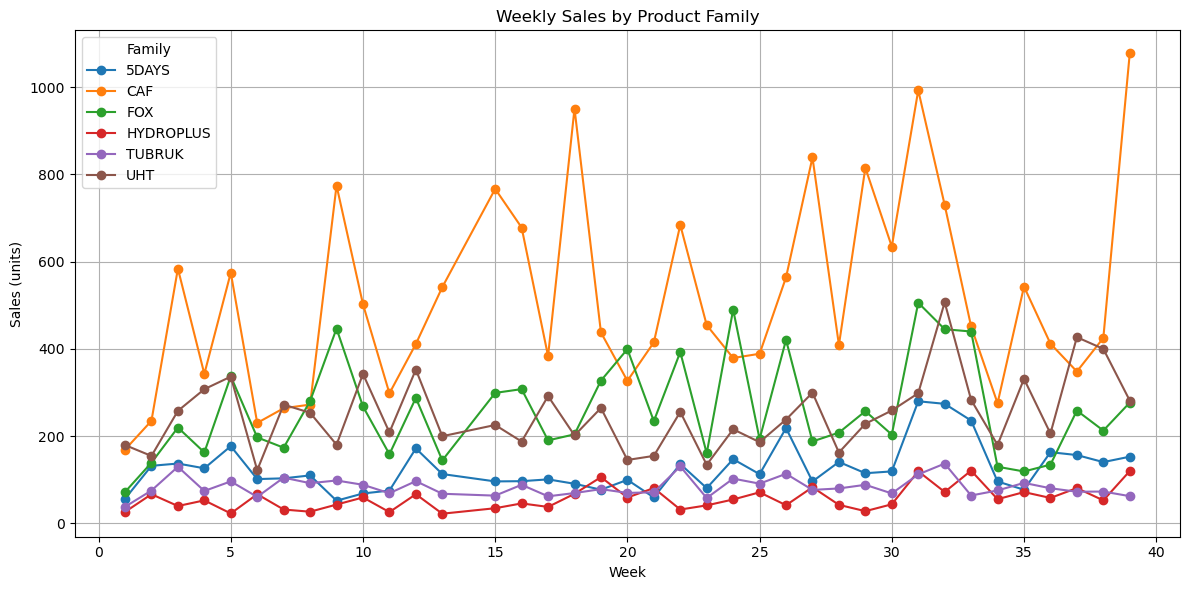

In [36]:
pivot_family = df_family.pivot(index="Week", columns="Family", values="Sales")

pivot_family.plot(figsize=(12, 6), marker="o")
plt.title("Weekly Sales by Product Family")
plt.xlabel("Week")
plt.ylabel("Sales (units)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Uji Stasioneritas (ADF Test)

In [37]:
print("=" * 80)
print("ADF STATIONARITY TEST")
print("=" * 80)

adf_results = []

for family in families:
    df_f   = df_family[df_family["Family"] == family].sort_values("Week")
    series = df_f["Sales"].astype(float)

    result = adfuller(series)

    adf_results.append({
        "Family":        family,
        "ADF Statistic": round(result[0], 4),
        "p-value":       round(result[1], 4),
        "Status":        "Stationary" if result[1] < 0.05 else "Non-Stationary"
    })

df_adf = pd.DataFrame(adf_results)
display(df_adf)


ADF STATIONARITY TEST


,Family,ADF Statistic,p-value,Status
0,5DAYS,-4.0503,0.0012,Stationary
1,CAF,-4.8618,0.0000,Stationary
2,FOX,-3.9464,0.0017,Stationary
3,HYDROPLUS,-0.7079,0.8447,Non-Stationary
4,TUBRUK,-7.2033,0.0000,Stationary
5,UHT,-1.8043,0.3783,Non-Stationary


## 10. Visualisasi ACF dan PACF

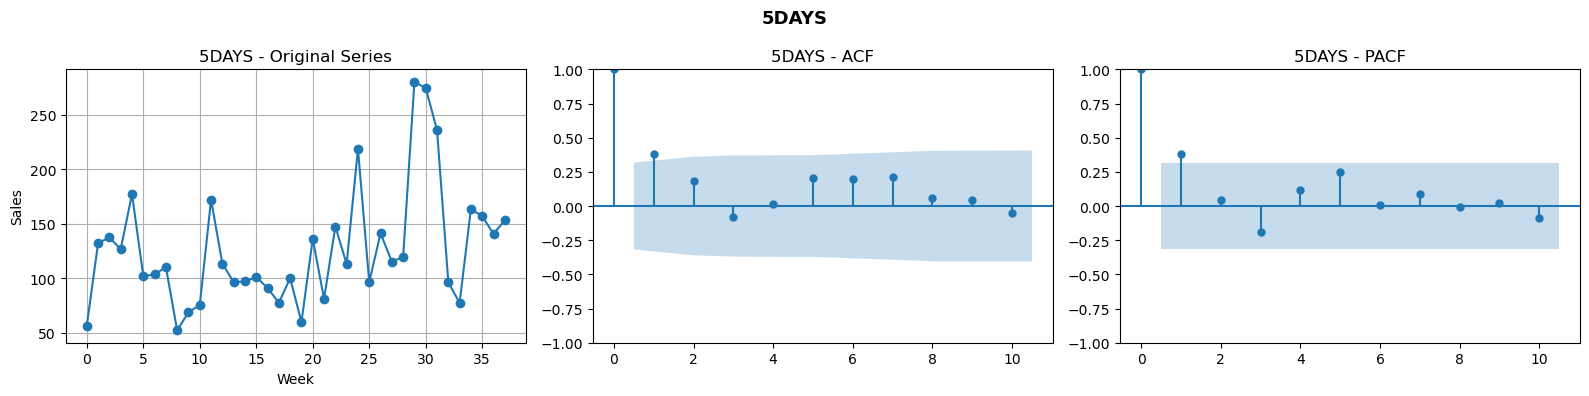

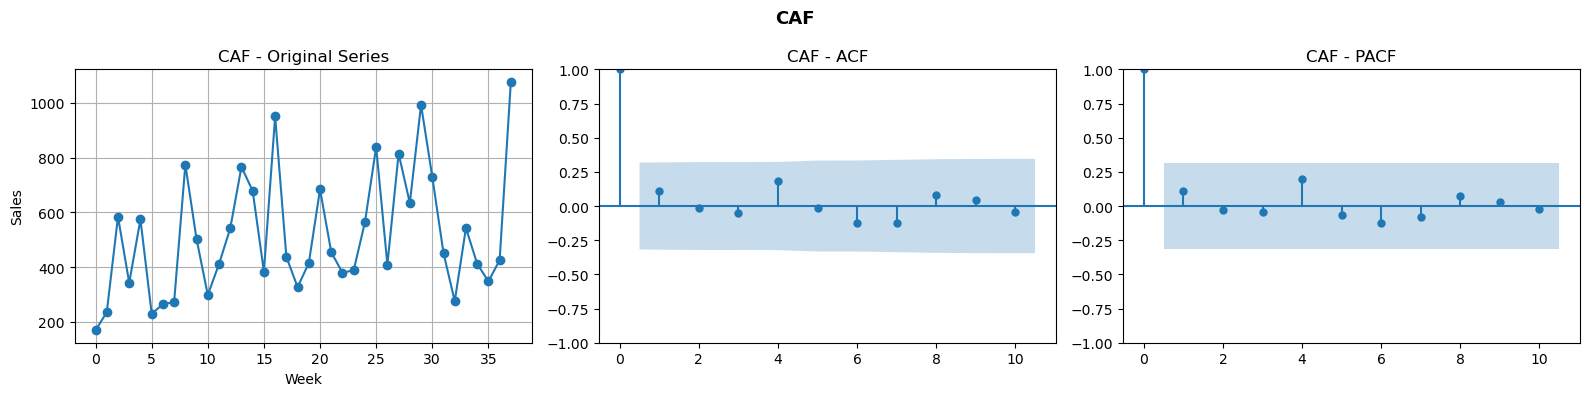

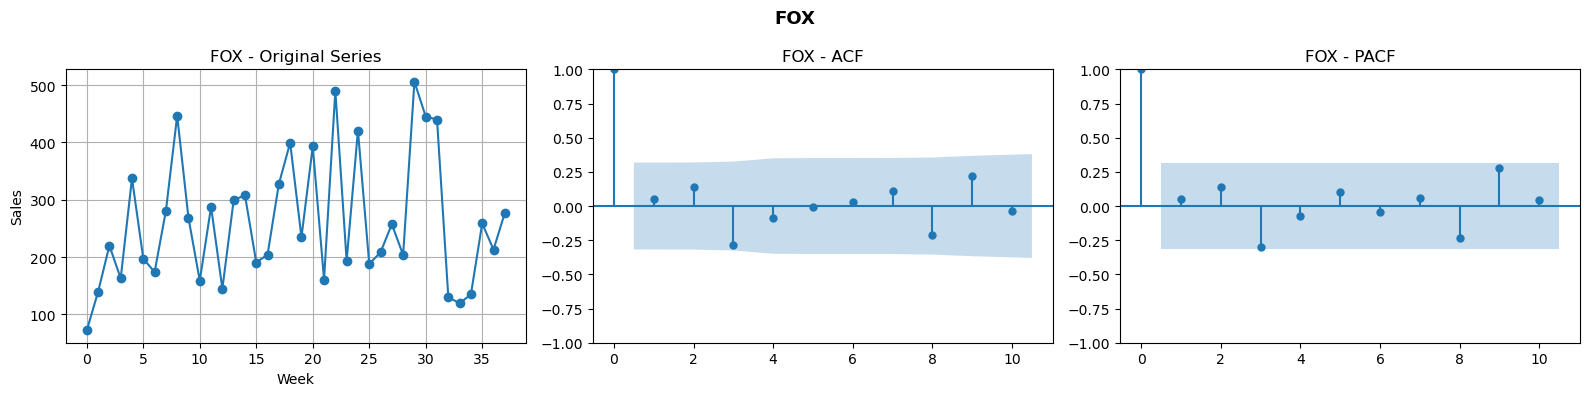

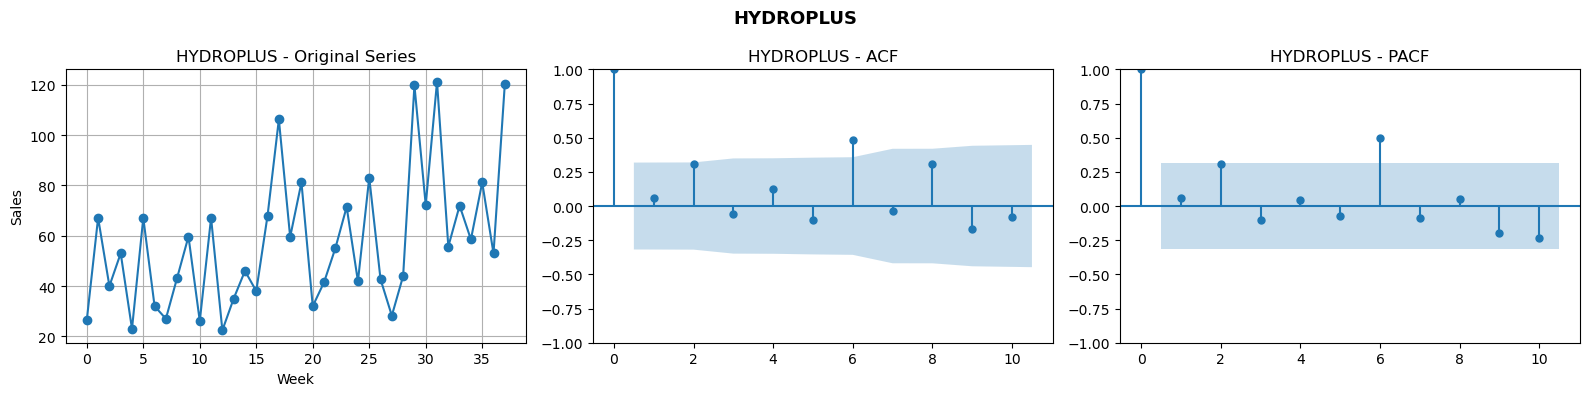

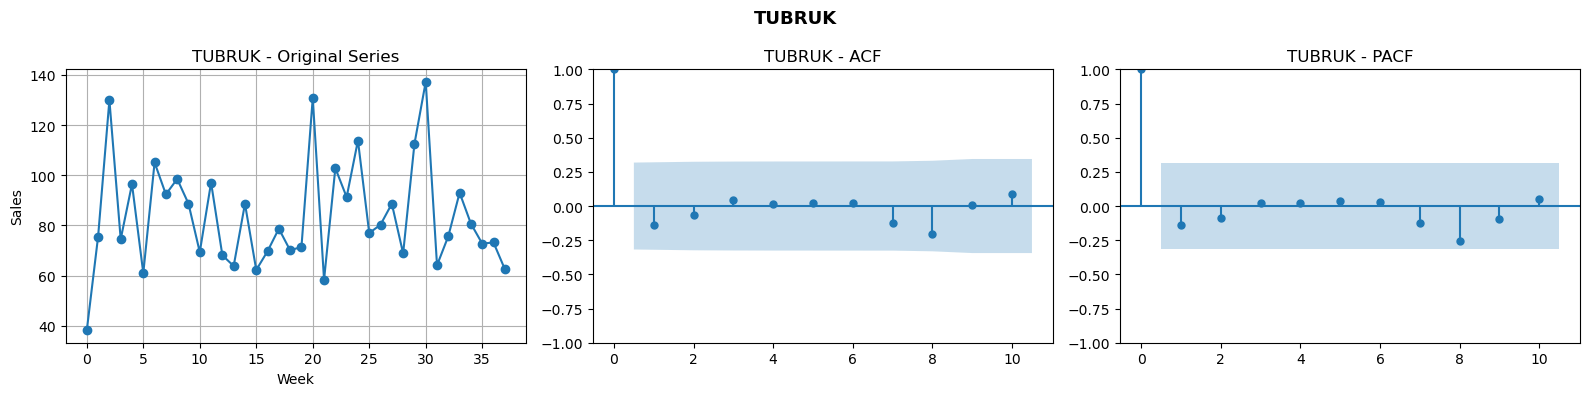

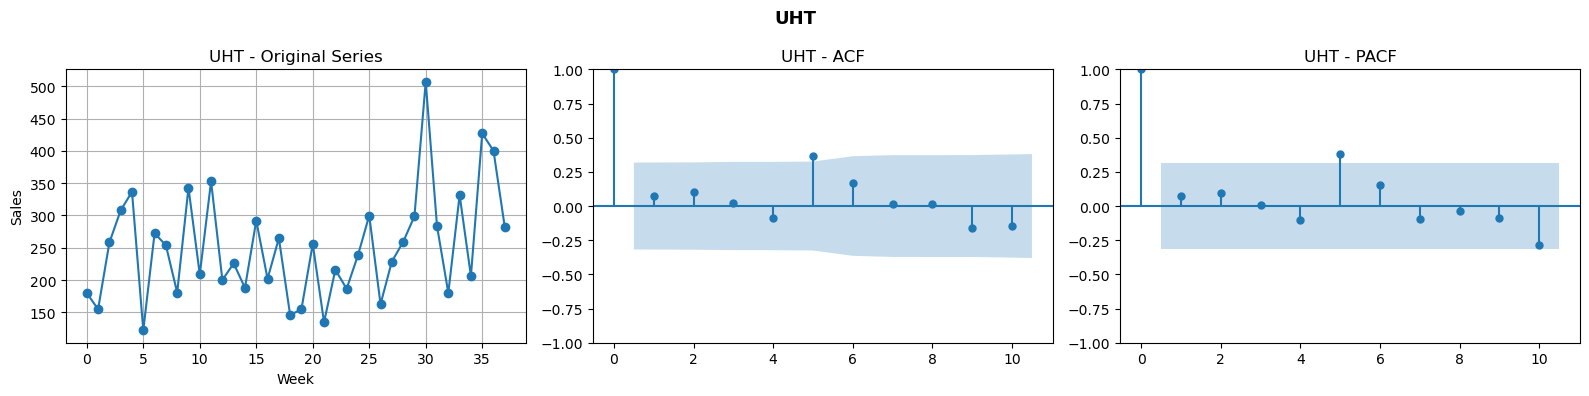

In [38]:
for family in families:
    df_f   = df_family[df_family["Family"] == family]
    series = df_f["Sales"].values.astype(float)

    max_lags = max(2, min(10, len(series) // 2 - 1))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(series, marker="o")
    axes[0].set_title(f"{family} - Original Series")
    axes[0].set_xlabel("Week")
    axes[0].set_ylabel("Sales")
    axes[0].grid(True)

    plot_acf(series, lags=max_lags, ax=axes[1])
    axes[1].set_title(f"{family} - ACF")

    plot_pacf(series, lags=max_lags, method="ywm", ax=axes[2])
    axes[2].set_title(f"{family} - PACF")

    plt.suptitle(family, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 11. Differencing Check

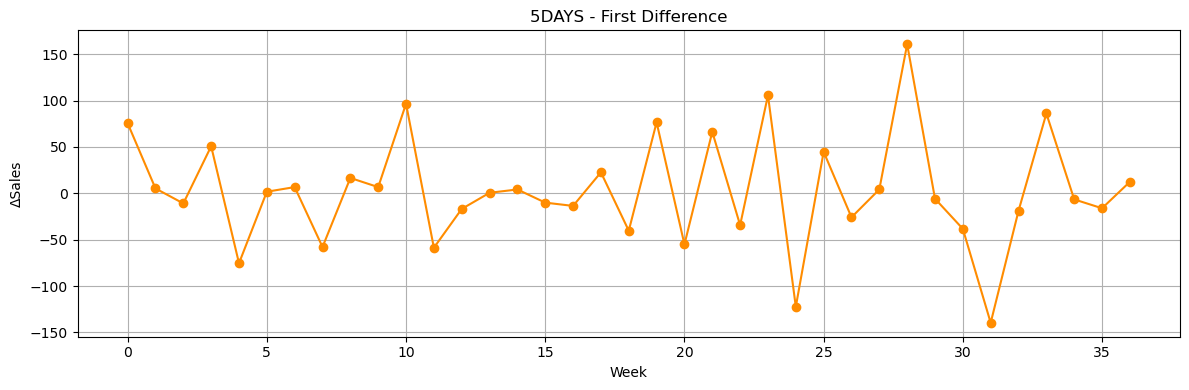

5DAYS        | Differenced ADF p-value = 0.0000 (Stationary)


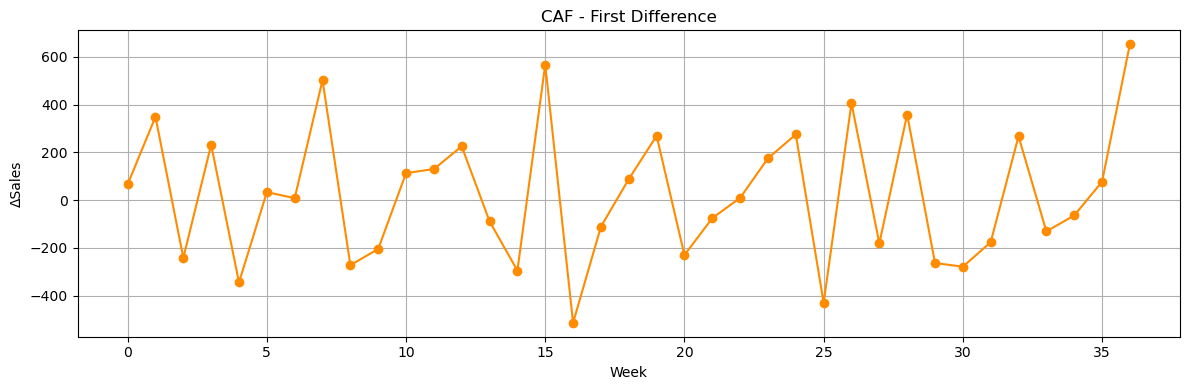

CAF          | Differenced ADF p-value = 0.0092 (Stationary)


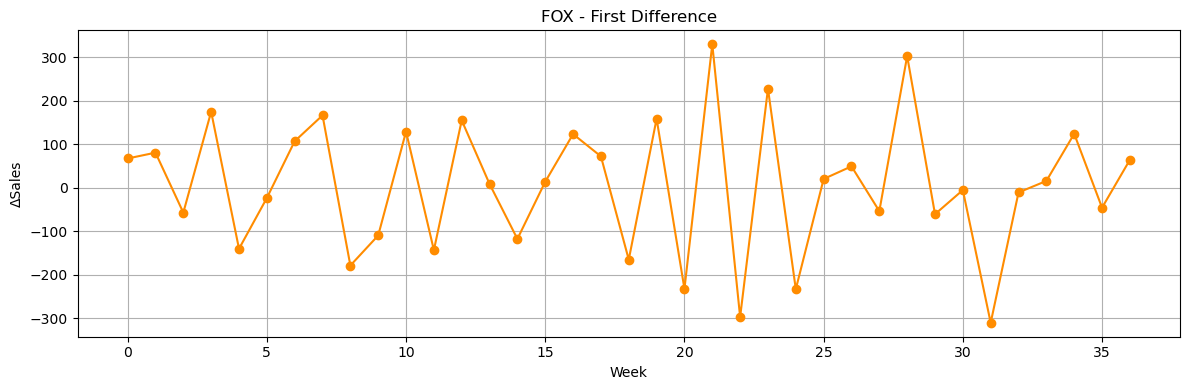

FOX          | Differenced ADF p-value = 0.0000 (Stationary)


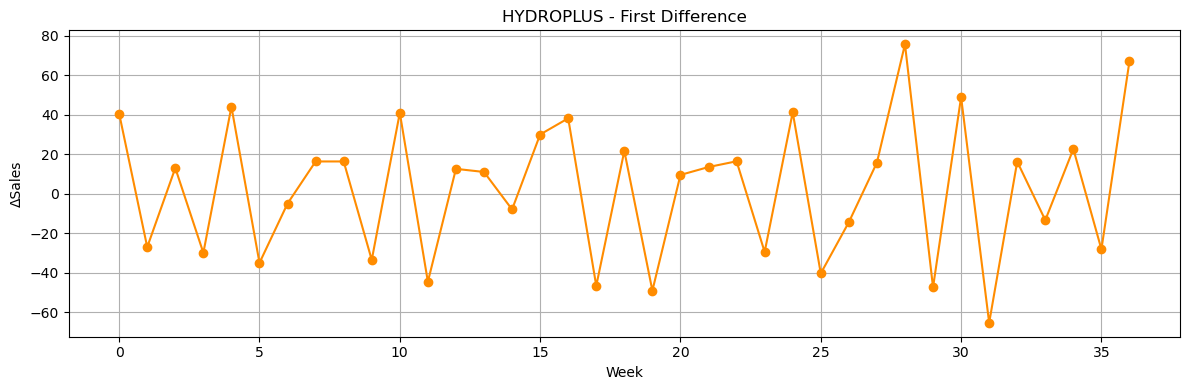

HYDROPLUS    | Differenced ADF p-value = 0.0082 (Stationary)


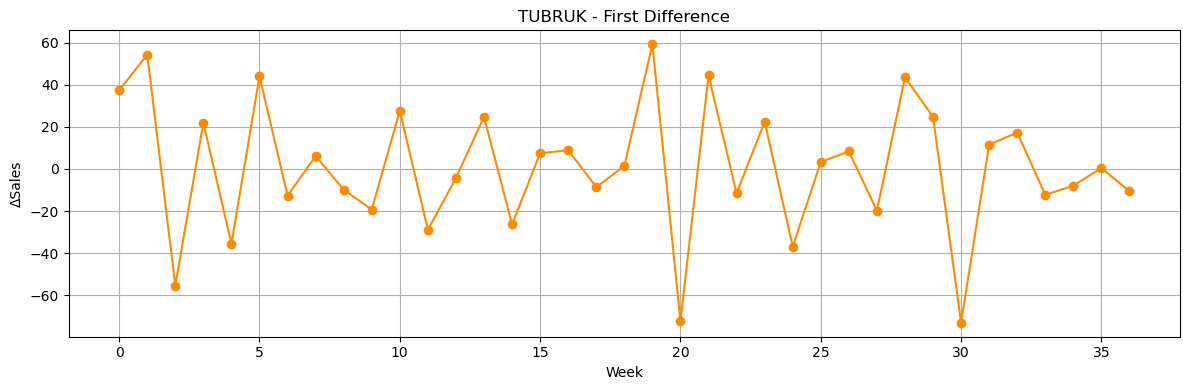

TUBRUK       | Differenced ADF p-value = 0.0000 (Stationary)


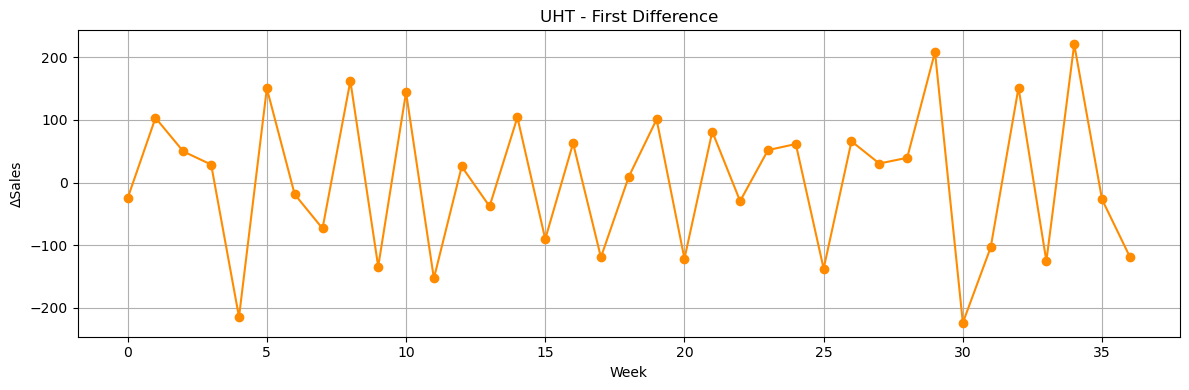

UHT          | Differenced ADF p-value = 0.0000 (Stationary)


In [39]:
for family in families:
    df_f        = df_family[df_family["Family"] == family]
    series      = df_f["Sales"].values.astype(float)
    diff_series = np.diff(series)

    plt.figure(figsize=(12, 4))
    plt.plot(diff_series, marker="o", color="darkorange")
    plt.title(f"{family} - First Difference")
    plt.xlabel("Week")
    plt.ylabel("ΔSales")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    result = adfuller(diff_series)
    print(
        f"{family:12} | "
        f"Differenced ADF p-value = {result[1]:.4f} "
        f"({'Stationary' if result[1] < 0.05 else 'Non-Stationary'})"
    )


## 12. Definisi Fungsi ARIMA dan Evaluasi

In [40]:
def fit_arima(train_series):
    train_series = pd.Series(train_series).astype(float)

    model = auto_arima(
        train_series,
        seasonal=False,
        start_p=0,
        start_q=0,
        max_p=ARIMA_MAX_P,
        max_d=2,
        max_q=ARIMA_MAX_Q,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        information_criterion="aicc",
        test="adf"
    )

    return model


def arima_forecast(model, steps, with_ci=False):
    if with_ci:
        forecast, conf_int = model.predict(
            n_periods=steps,
            return_conf_int=True
        )
        return np.array(forecast), conf_int

    forecast = model.predict(n_periods=steps)
    return np.array(forecast)


def smape(actual, pred):
    actual = np.array(actual)
    pred   = np.array(pred)

    denominator = np.abs(actual) + np.abs(pred)

    return np.mean(
        np.where(
            denominator == 0,
            0,
            2 * np.abs(actual - pred) / denominator
        )
    ) * 100


def evaluate_forecast(actual, pred):
    actual = np.array(actual)
    pred   = np.array(pred)

    mae       = np.mean(np.abs(actual - pred))
    rmse      = np.sqrt(np.mean((actual - pred) ** 2))
    smape_val = smape(actual, pred)

    return {"MAE": mae, "RMSE": rmse, "sMAPE": smape_val}


## 13. Training dan Evaluasi Model ARIMA

In [41]:
print("=" * 80)
print("TRAINING + EVALUATION (FAMILY LEVEL ARIMA)")
print("=" * 80)

results     = []
eval_models = {}

for family in families:
    df_f   = df_family[df_family["Family"] == family].copy()
    series = df_f["Sales"].values.astype(float)

    if len(series) <= TEST_SIZE:
        print(f"SKIP: {family} (series too short)")
        continue

    train = series[:-TEST_SIZE]
    test  = series[-TEST_SIZE:]

    model = fit_arima(train)
    pred  = arima_forecast(model, TEST_SIZE)
    pred  = np.clip(pred, 0, None)

    metrics = evaluate_forecast(test, pred)

    eval_models[family] = {
        "model": model,
        "train": train,
        "test":  test,
        "pred":  pred
    }

    results.append({
        "Family":        family,
        "Order":         model.order,
        "MAE":           metrics["MAE"],
        "RMSE":          metrics["RMSE"],
        "sMAPE":         metrics["sMAPE"],
        "HistoricalAvg": np.mean(series)
    })

    print(
        f"{family:12} | "
        f"ARIMA{model.order} | "
        f"MAE={metrics['MAE']:.2f} | "
        f"RMSE={metrics['RMSE']:.2f} | "
        f"sMAPE={metrics['sMAPE']:.2f}%"
    )

df_results = pd.DataFrame(results).sort_values("sMAPE").reset_index(drop=True)
print()
df_results


TRAINING + EVALUATION (FAMILY LEVEL ARIMA)
5DAYS        | ARIMA(0, 1, 1) | MAE=38.66 | RMSE=49.77 | sMAPE=27.12%
CAF          | ARIMA(0, 1, 1) | MAE=212.08 | RMSE=265.84 | sMAPE=35.25%
FOX          | ARIMA(0, 0, 0) | MAE=71.88 | RMSE=93.80 | sMAPE=34.81%
HYDROPLUS    | ARIMA(3, 2, 0) | MAE=18.88 | RMSE=23.04 | sMAPE=21.44%
TUBRUK       | ARIMA(2, 1, 1) | MAE=11.29 | RMSE=13.37 | sMAPE=14.48%
UHT          | ARIMA(2, 1, 0) | MAE=73.53 | RMSE=96.50 | sMAPE=23.26%



,Family,Order,MAE,RMSE,sMAPE,HistoricalAvg
0,TUBRUK,"(2, 1, 1)",11.294950,13.369448,14.483938,83.785039
1,HYDROPLUS,"(3, 2, 0)",18.876669,23.042407,21.439481,57.408177
2,UHT,"(2, 1, 0)",73.532243,96.499988,23.256356,251.020487
3,5DAYS,"(0, 1, 1)",38.662598,49.774775,27.119398,126.209704
4,FOX,"(0, 0, 0)",71.880857,93.803514,34.812551,260.325067
5,CAF,"(0, 1, 1)",212.082669,265.836350,35.250312,515.442322


## 14. Ringkasan Evaluasi

In [42]:
print("=" * 80)
print("EVALUATION SUMMARY")
print("=" * 80)

print("Total families:", len(df_results))

print("\nARIMA orders:")
print(df_results["Order"].value_counts())

print("\nMetrics summary:")
print(df_results[["MAE", "RMSE", "sMAPE"]].describe().round(2))


EVALUATION SUMMARY
Total families: 6

ARIMA orders:
Order
(0, 1, 1)    2
(2, 1, 1)    1
(3, 2, 0)    1
(2, 1, 0)    1
(0, 0, 0)    1
Name: count, dtype: int64

Metrics summary:
          MAE    RMSE  sMAPE
count    6.00    6.00   6.00
mean    71.05   90.39  26.06
std     73.81   92.68   8.07
min     11.29   13.37  14.48
25%     23.82   29.73  21.89
50%     55.27   71.79  25.19
75%     73.12   95.83  32.89
max    212.08  265.84  35.25


## 15. Forecast 5 Minggu ke Depan

In [43]:
# ============================================================
# FORECAST 5 MINGGU KE DEPAN (dengan CI yang benar)
# ============================================================

future_forecasts = []
final_models     = {}

for family in families:
    df_f   = df_family[df_family["Family"] == family].copy()
    series = df_f["Sales"].values.astype(float)

    model              = fit_arima(series)
    forecast, conf_int = arima_forecast(model, FORECAST_HORIZON, with_ci=True)

    lower_ci_raw = conf_int[:, 0]
    upper_ci_raw = conf_int[:, 1]

    # ❌ HAPUS kode lama yang menyebabkan CI = forecast
    # forecast_mean = np.mean(forecast)
    # forecast_std  = np.std(forecast)
    # lower_floor = np.maximum(0, forecast - 2 * forecast_std)
    # lower_ci    = np.maximum(lower_ci_raw, lower_floor)
    # upper_ci    = np.maximum(upper_ci_raw, lower_ci + 0.01)
    # upper_cap   = forecast * 2.5 + forecast_std * 2
    # upper_ci    = np.minimum(upper_ci, upper_cap)

    # ✅ Gunakan CI langsung dari model, cukup clamp ke 0 untuk lower bound
    # Pakai CI langsung dari statsmodels, hanya enforce dua rule sederhana
    lower_ci = np.clip(lower_ci_raw, 0, None)          # floor di 0
    upper_ci = np.maximum(upper_ci_raw, lower_ci + 0.01)  # upper selalu > lower

    # Opsional: pastikan upper > lower (untuk jaga-jaga)
    upper_ci = np.maximum(upper_ci, lower_ci + 0.01)

    final_models[family] = {
        "model":    model,
        "series":   series,
        "forecast": forecast,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci,
    }

    future_forecasts.append({
        "Family":        family,
        "FinalOrder":    model.order,
        "HistoricalAvg": round(np.mean(series), 2),
        "ForecastAvg":   round(np.mean(forecast), 2),
        "Forecast":      list(np.round(forecast, 2)),
        "LowerCI":       list(np.round(lower_ci, 2)),
        "UpperCI":       list(np.round(upper_ci, 2))
    })

df_future = pd.DataFrame(future_forecasts)
display(df_future.sort_values("HistoricalAvg", ascending=False).reset_index(drop=True))

,Family,FinalOrder,HistoricalAvg,ForecastAvg,Forecast,LowerCI,UpperCI
0,CAF,"(0, 1, 1)",515.44,580.22,"[580.22, 580.22, 580.22, 580.22, 580.22]","[131.69, 128.16, 124.66, 121.19, 117.74]","[1028.75, 1032.27, 1035.77, 1039.25, 1042.69]"
1,FOX,"(0, 0, 0)",260.33,260.33,"[260.33, 260.33, 260.33, 260.33, 260.33]","[40.44, 40.44, 40.44, 40.44, 40.44]","[480.21, 480.21, 480.21, 480.21, 480.21]"
2,UHT,"(0, 1, 1)",251.02,305.89,"[305.89, 305.89, 305.89, 305.89, 305.89]","[139.4, 136.98, 134.59, 132.24, 129.92]","[472.39, 474.81, 477.2, 479.55, 481.87]"
3,5DAYS,"(0, 1, 0)",126.21,153.09,"[153.09, 153.09, 153.09, 153.09, 153.09]","[36.14, 0.0, 0.0, 0.0, 0.0]","[270.03, 318.48, 355.65, 386.98, 414.59]"
4,TUBRUK,"(3, 1, 0)",83.79,71.08,"[74.38, 70.86, 69.16, 69.58, 71.44]","[28.49, 24.79, 21.92, 18.42, 16.67]","[120.27, 116.94, 116.41, 120.73, 126.21]"
5,HYDROPLUS,"(0, 0, 0)",57.41,57.41,"[57.41, 57.41, 57.41, 57.41, 57.41]","[5.21, 5.21, 5.21, 5.21, 5.21]","[109.61, 109.61, 109.61, 109.61, 109.61]"


## 16. Visualisasi Train / Test / Forecast

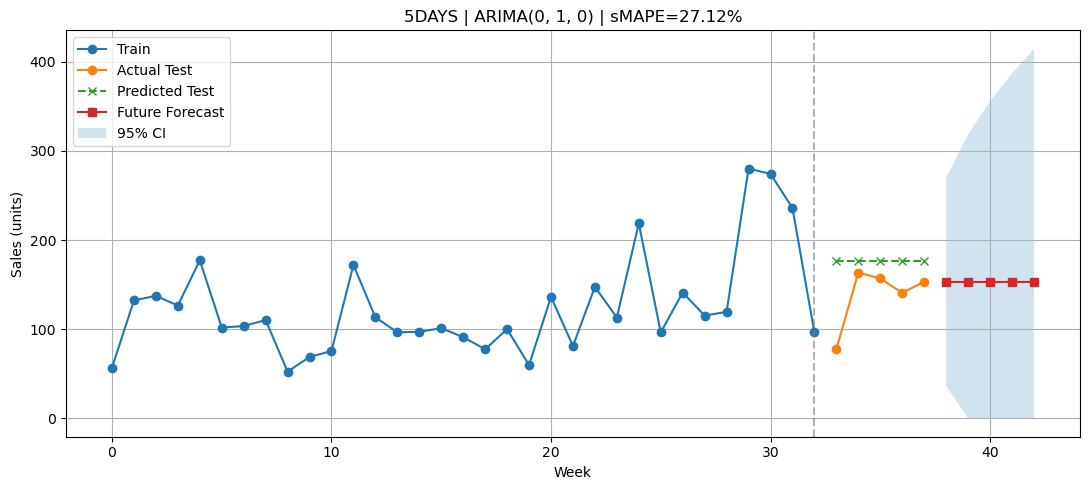

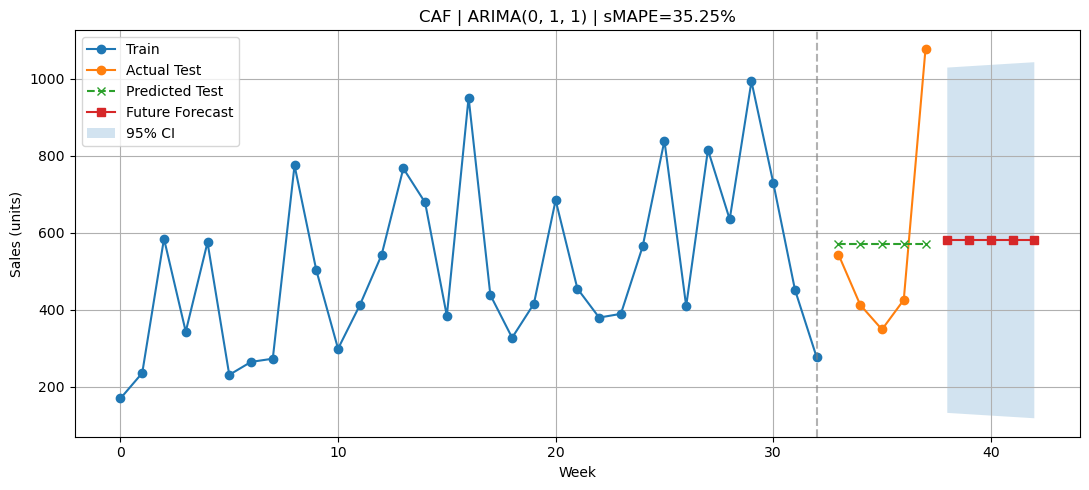

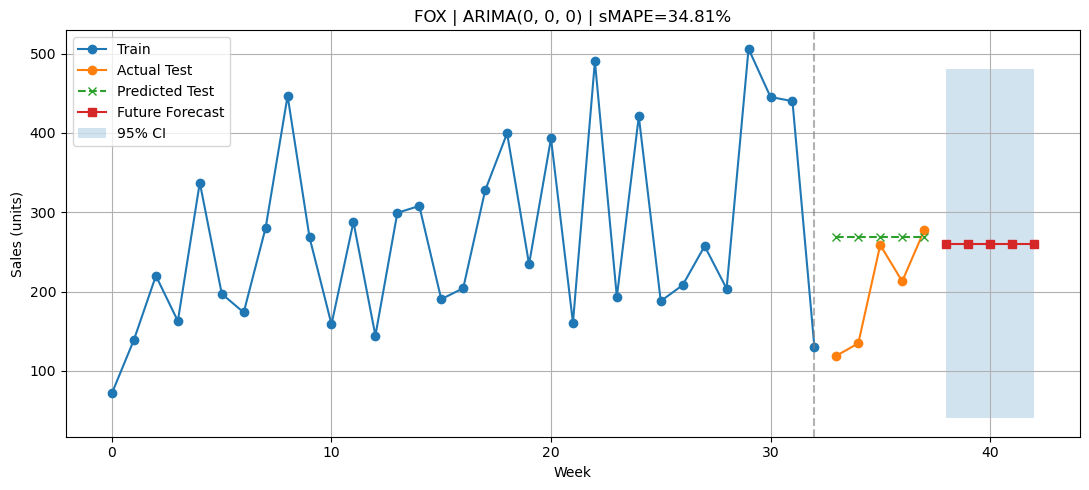

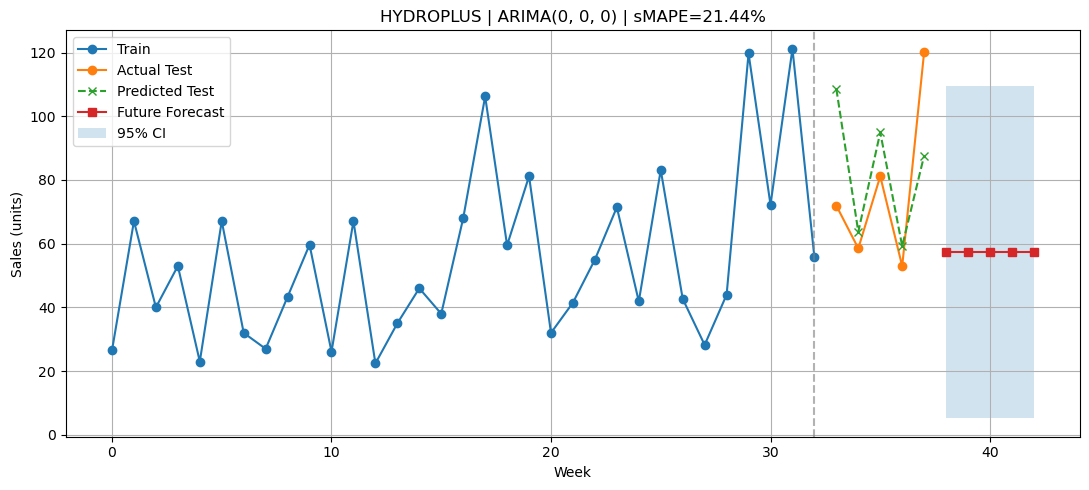

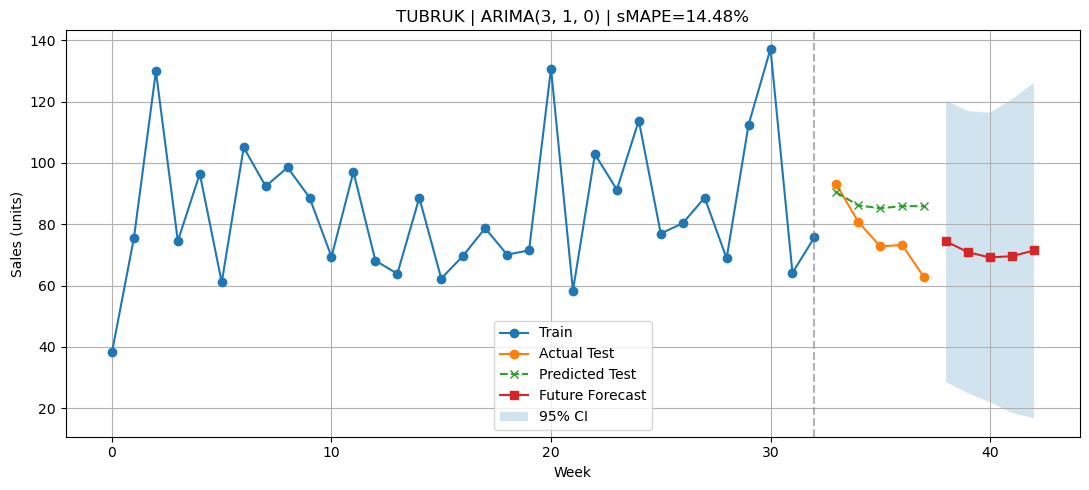

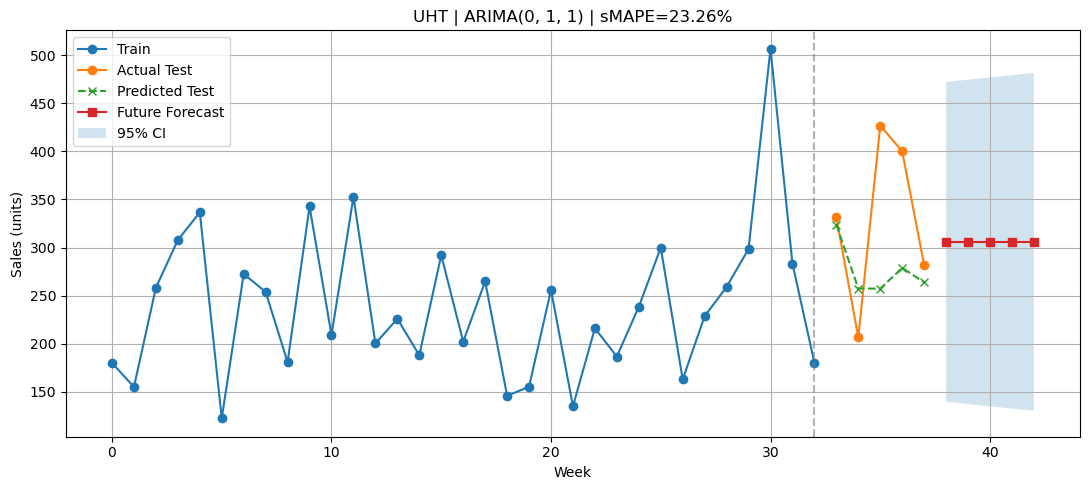

In [44]:
metrics_lookup = df_results.set_index("Family").to_dict("index")

for family in families:
    if family not in eval_models or family not in final_models:
        continue

    eval_data  = eval_models[family]
    final_data = final_models[family]

    train    = eval_data["train"]
    test     = eval_data["test"]
    pred     = eval_data["pred"]
    lower_ci = final_data["lower_ci"]
    upper_ci = final_data["upper_ci"]
    order    = final_data["model"].order
    metric   = metrics_lookup[family]

    x_train  = range(len(train))
    x_test   = range(len(train), len(train) + len(test))
    x_future = range(len(train) + len(test),
                     len(train) + len(test) + FORECAST_HORIZON)

    plt.figure(figsize=(11, 5))

    plt.plot(x_train,  train,                  marker="o", label="Train")
    plt.plot(x_test,   test,                   marker="o", label="Actual Test")
    plt.plot(x_test,   pred,                   marker="x", linestyle="--", label="Predicted Test")
    plt.plot(x_future, final_data["forecast"], marker="s", label="Future Forecast")

    plt.fill_between(x_future, lower_ci, upper_ci, alpha=0.2, label="95% CI")

    plt.axvline(len(train) - 1, linestyle="--", color="gray", alpha=0.6)

    plt.title(f"{family} | ARIMA{order} | sMAPE={metric['sMAPE']:.2f}%")
    plt.xlabel("Week")
    plt.ylabel("Sales (units)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


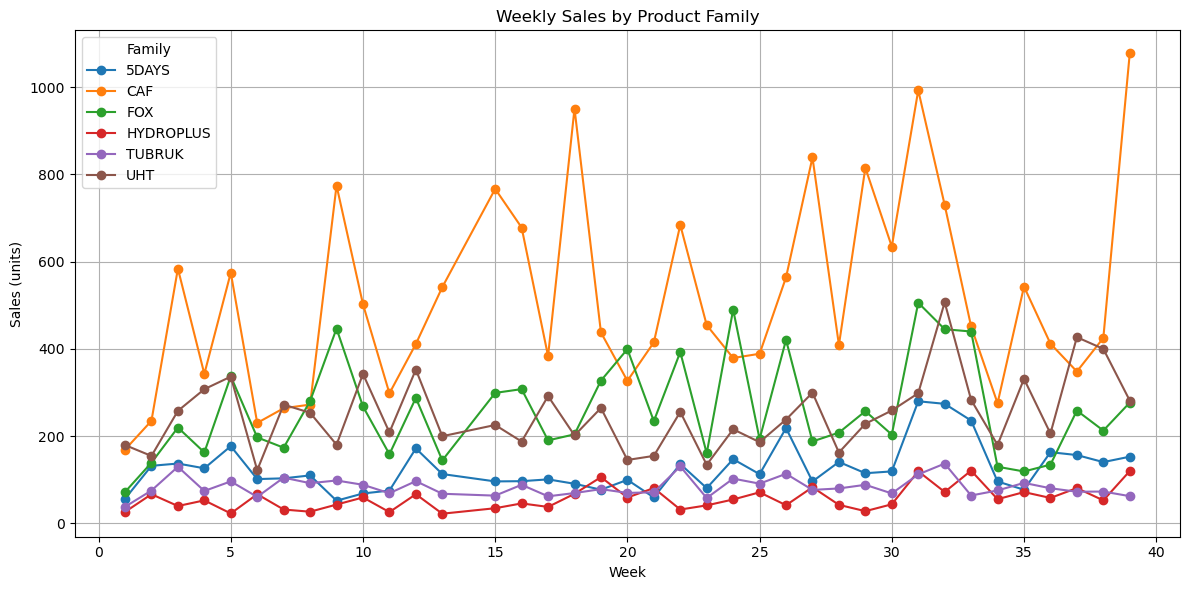

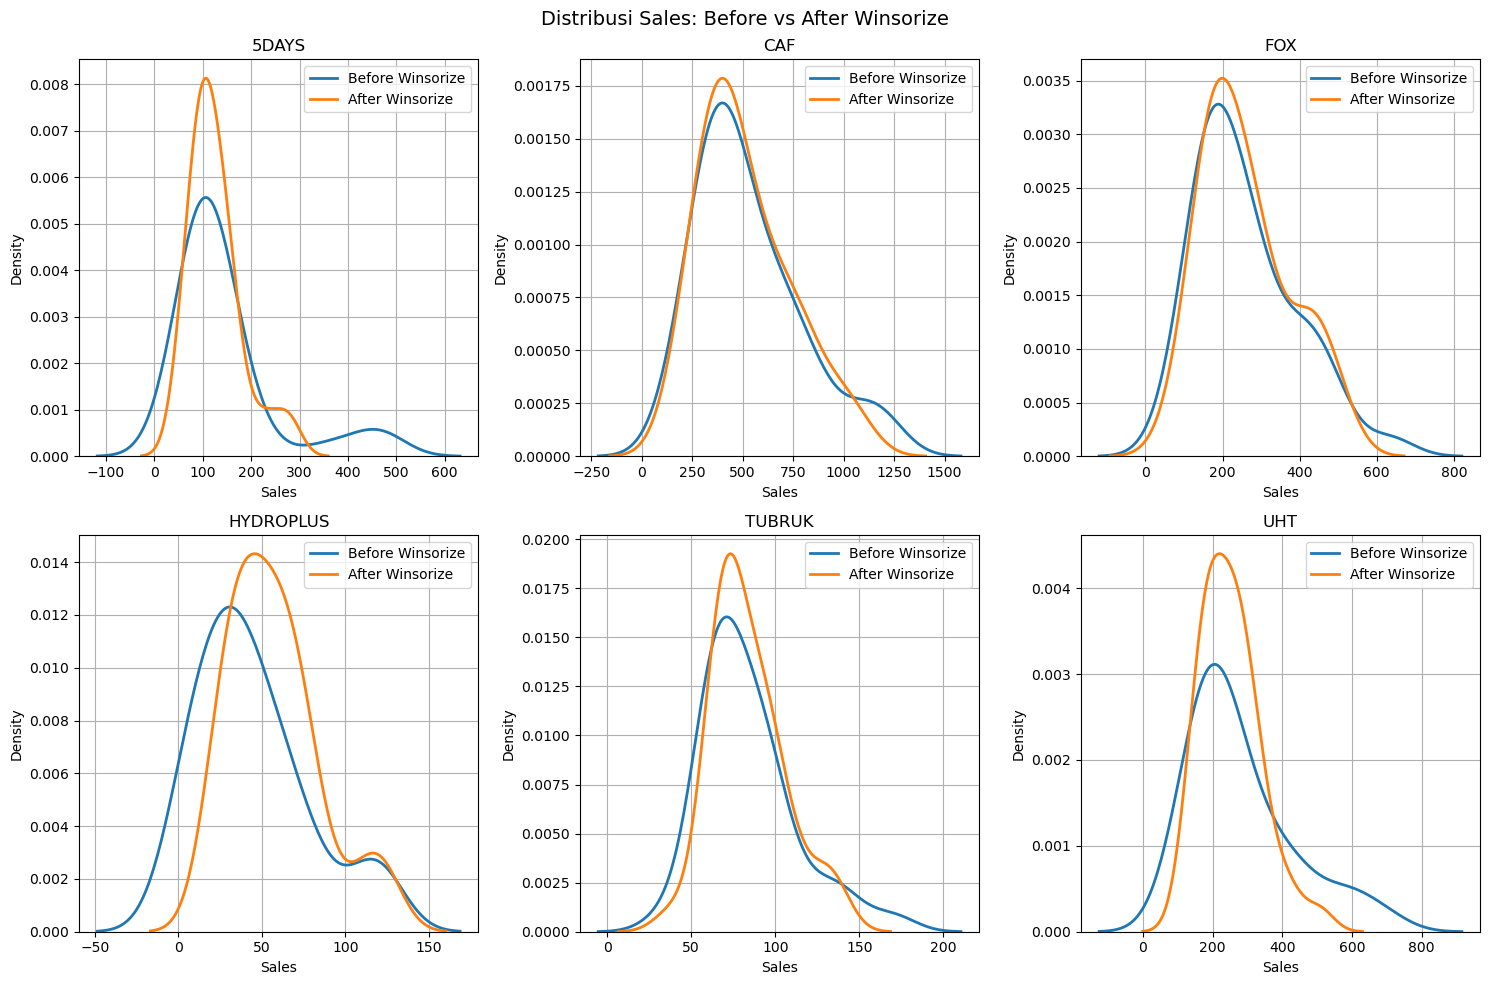

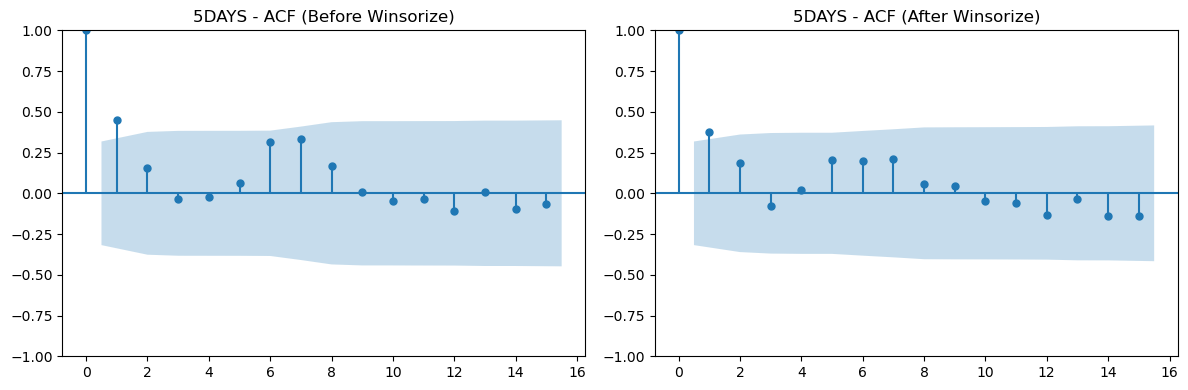

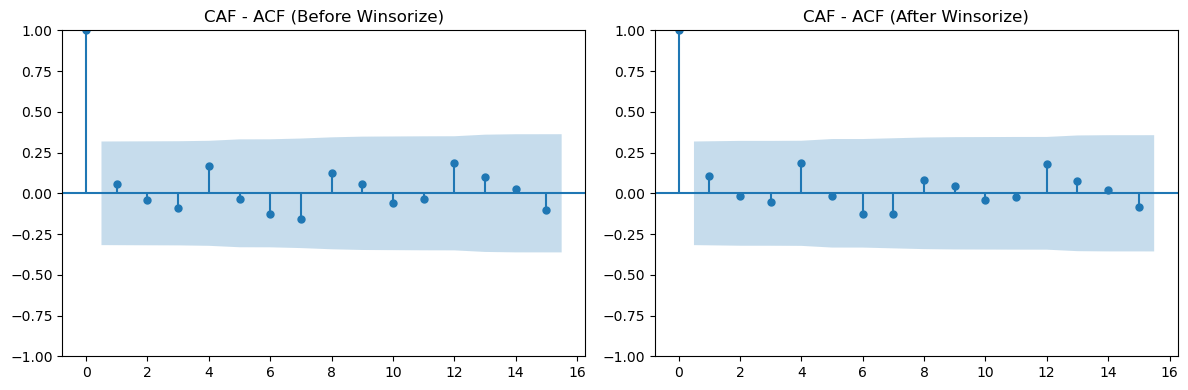

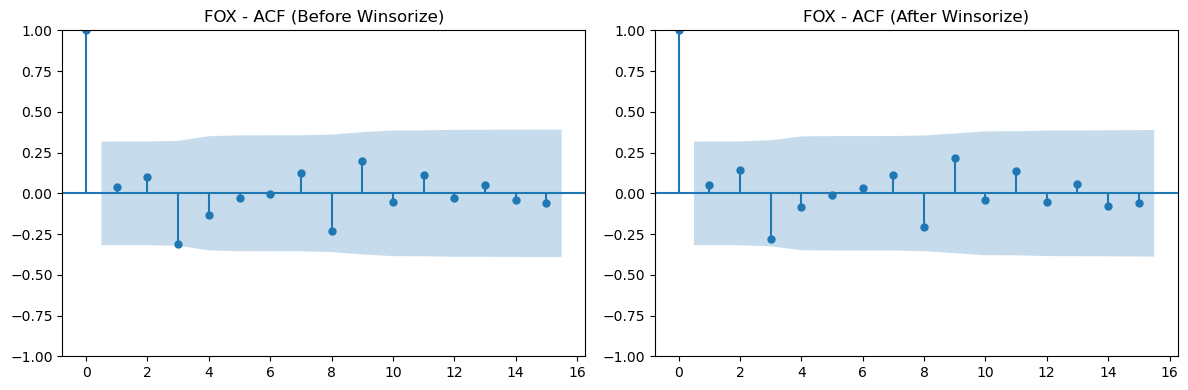

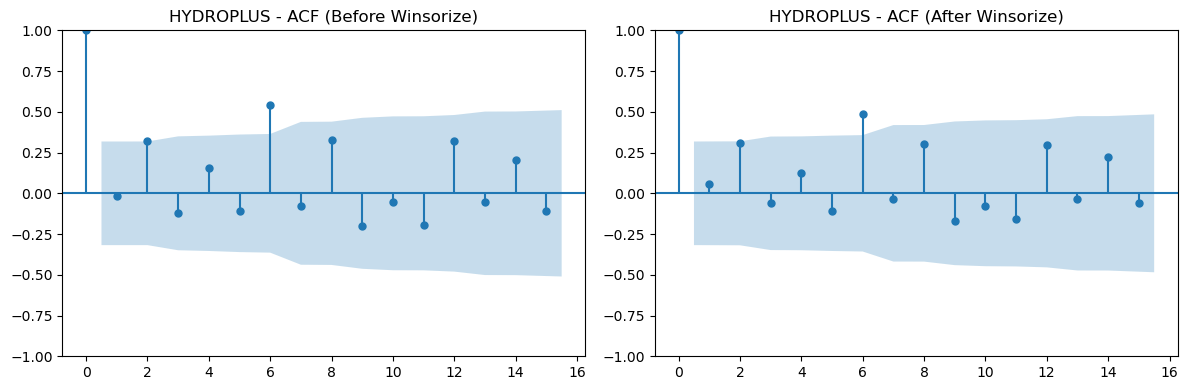

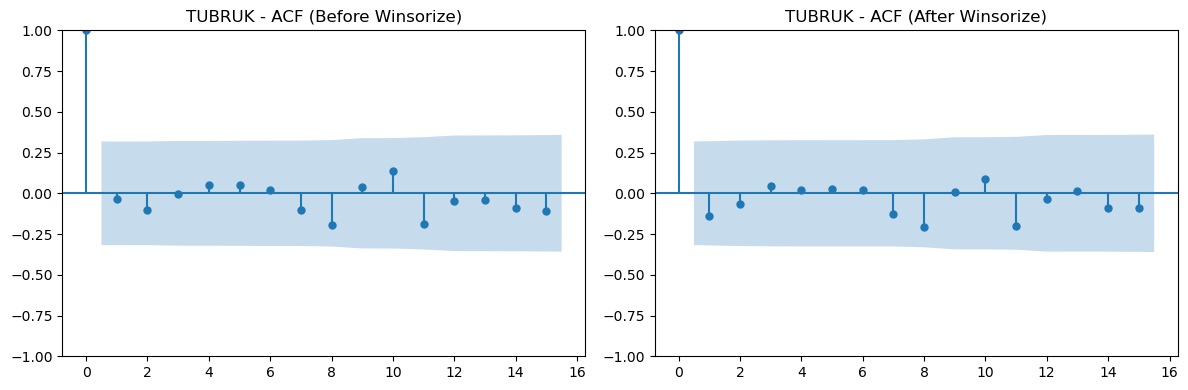

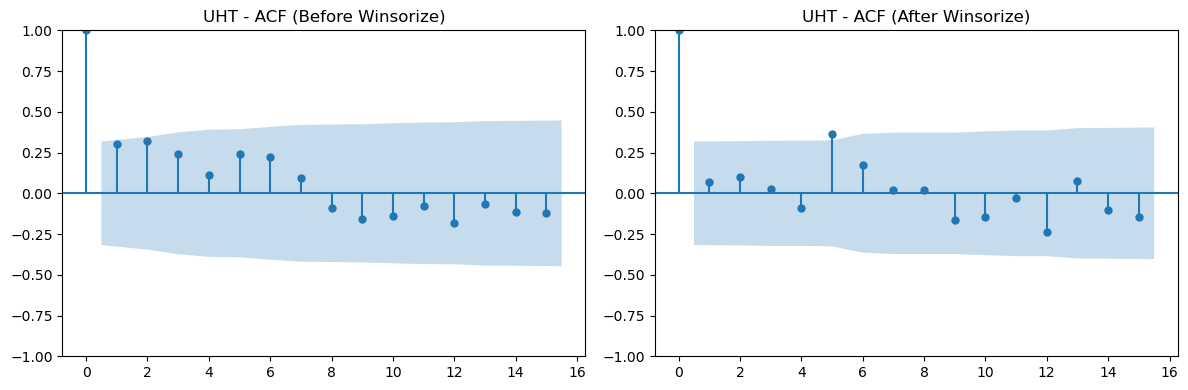

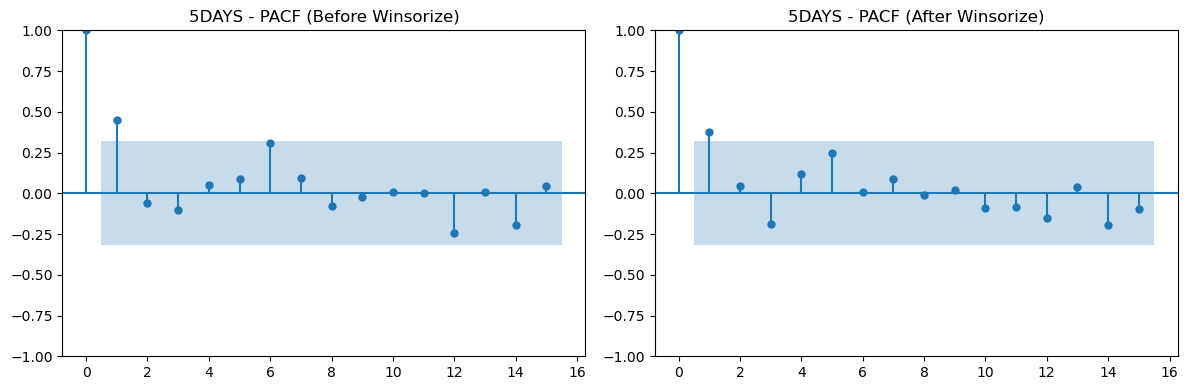

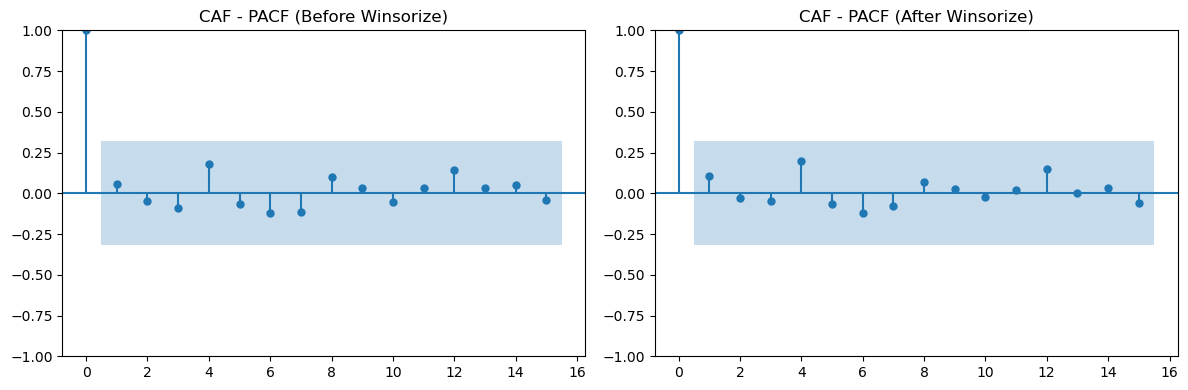

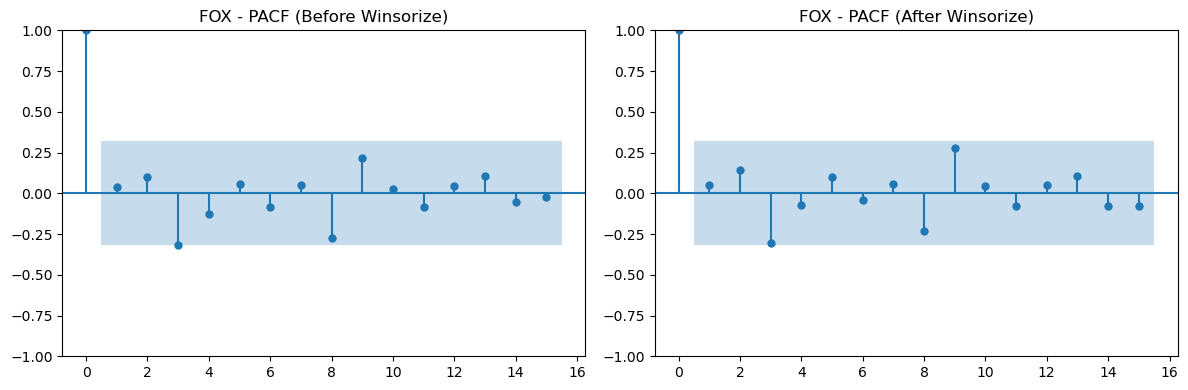

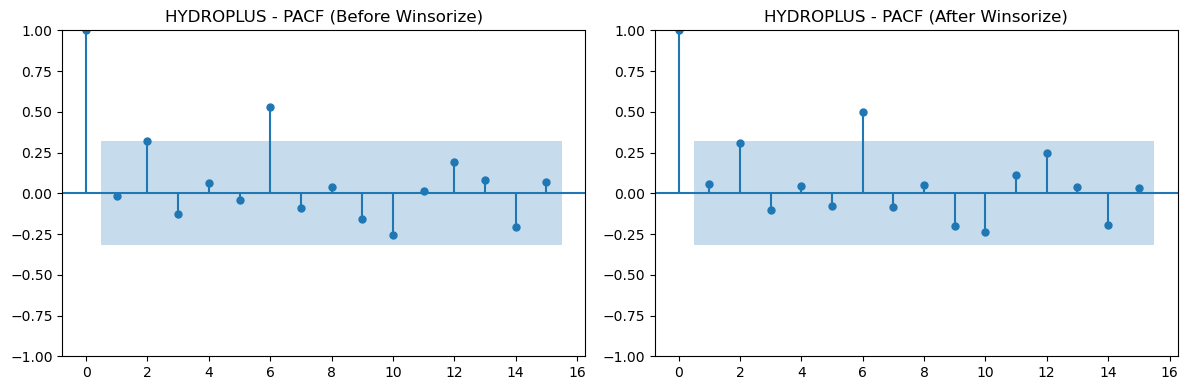

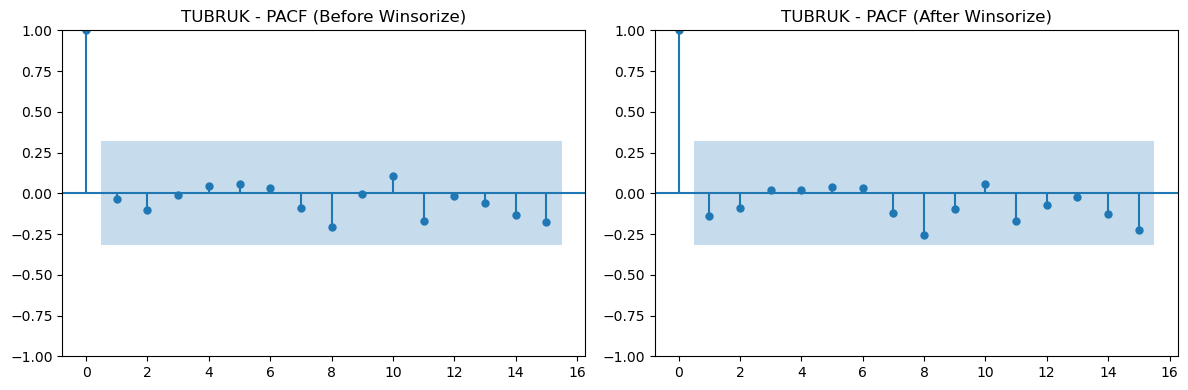

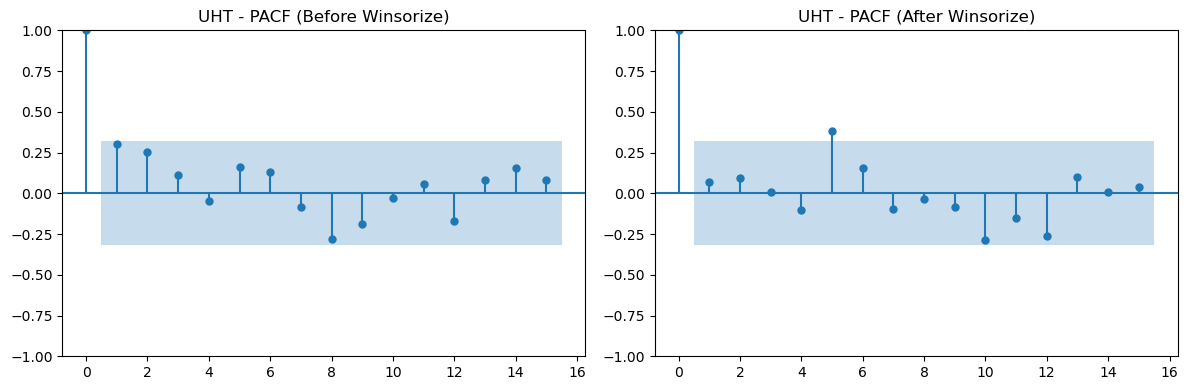

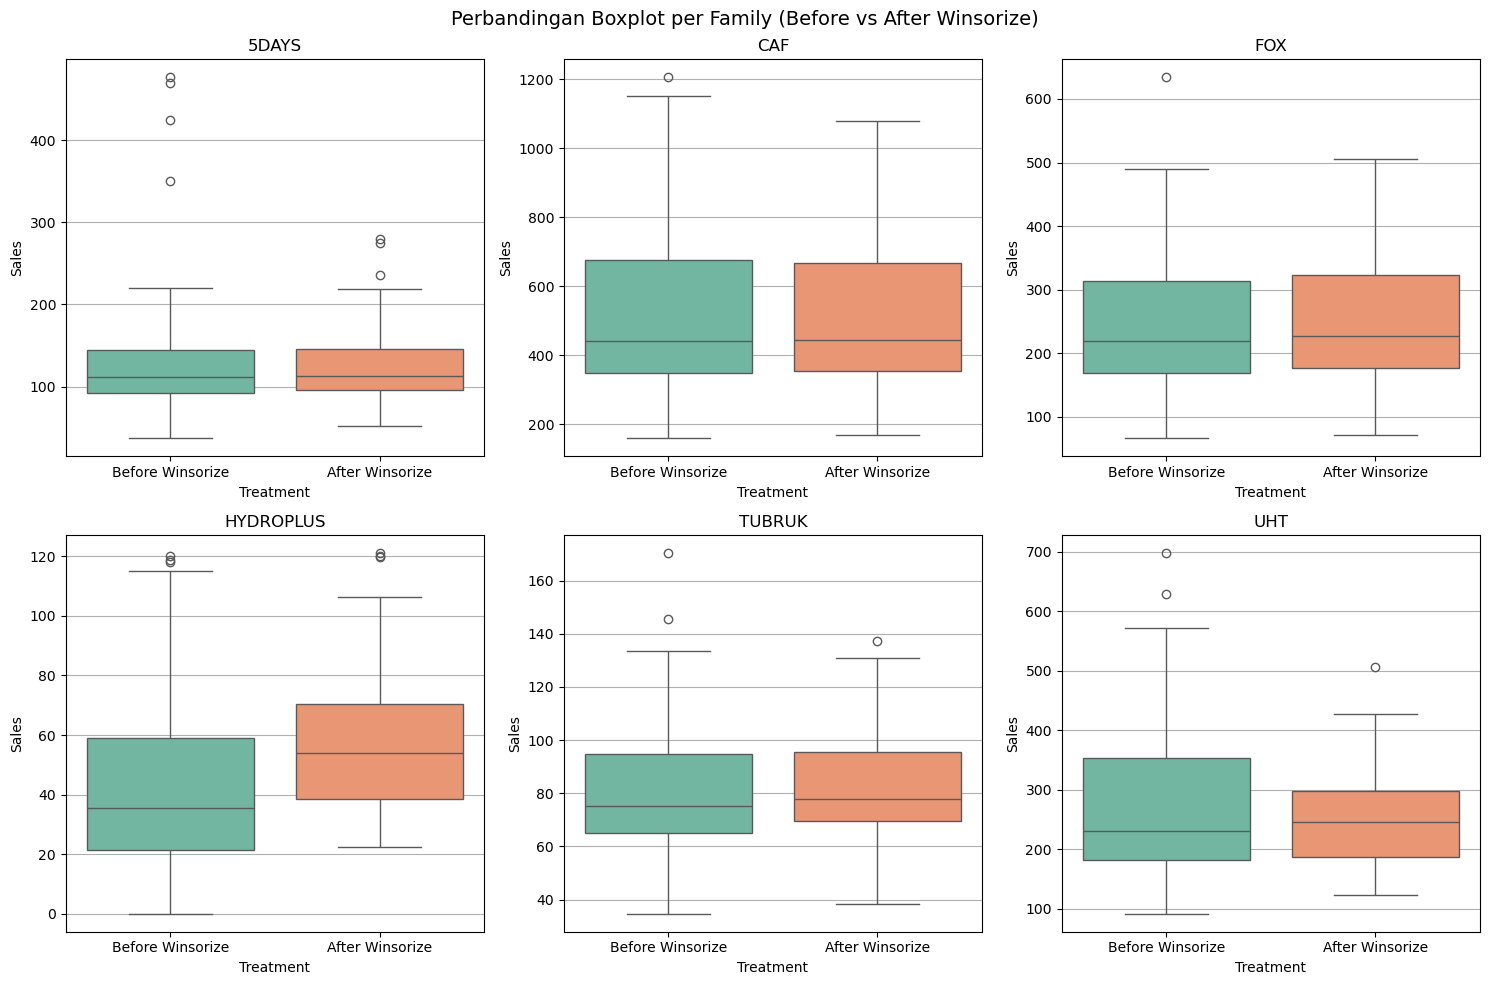

In [45]:
# ============================================================
# VISUALISASI PERBANDINGAN SEBELUM VS SESUDAH WINSORIZE (DIPERBAIKI)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pastikan df_long (before winsorize) dan df_family (after winsorize) tersedia
families = sorted(df_family['Family'].unique())

# ------------------------------------------------------------------
# Fungsi untuk mendapatkan data agregat per family sebelum winsorize
# (untuk minggu 1-40, tanpa mempertimbangkan minggu yang hilang)
# ------------------------------------------------------------------
def get_before_data(family):
    products = df_full_long[df_full_long['Family'] == family]['Product'].unique()
    df_prod = df_long[df_long['Product'].isin(products)]
    # Agregasi ke minggu 1-40, isi NaN dengan 0 (karena tidak ada data sama sekali)
    before_agg = df_prod.groupby('Week')['Sales'].sum().reindex(range(1, 41)).fillna(0).values
    return before_agg

# ------------------------------------------------------------------
# 1. Weekly Sales Trend (sebelum vs sesudah) - dengan minggu yang sama
# ------------------------------------------------------------------
pivot_family = df_family.pivot(index="Week", columns="Family", values="Sales")

pivot_family.plot(figsize=(12, 6), marker="o")
plt.title("Weekly Sales by Product Family")
plt.xlabel("Week")
plt.ylabel("Sales (units)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 2. Distribusi (KDE) sebelum vs sesudah - dengan data yang sama panjang
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, family in enumerate(families):
    after_df = df_family[df_family['Family'] == family].sort_values('Week')
    weeks = after_df['Week'].values
    after = after_df['Sales'].values

    before_full = get_before_data(family)
    before_dict = {week: before_full[week-1] for week in range(1, 41)}
    before = np.array([before_dict[w] for w in weeks])

    ax = axes[i]
    sns.kdeplot(before, label='Before Winsorize', ax=ax, linewidth=2)
    sns.kdeplot(after, label='After Winsorize', ax=ax, linewidth=2)
    ax.set_title(family)
    ax.set_xlabel('Sales')
    ax.legend()
    ax.grid(True)

plt.suptitle('Distribusi Sales: Before vs After Winsorize', fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. ACF (sebelum vs sesudah)
# ------------------------------------------------------------------
max_lags = 15
for family in families:
    after_df = df_family[df_family['Family'] == family].sort_values('Week')
    weeks = after_df['Week'].values
    after = after_df['Sales'].values

    before_full = get_before_data(family)
    before_dict = {week: before_full[week-1] for week in range(1, 41)}
    before = np.array([before_dict[w] for w in weeks])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(before, lags=min(max_lags, len(before)-1), ax=ax1, title=f'{family} - ACF (Before Winsorize)')
    plot_acf(after, lags=min(max_lags, len(after)-1), ax=ax2, title=f'{family} - ACF (After Winsorize)')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 4. PACF (sebelum vs sesudah)
# ------------------------------------------------------------------
for family in families:
    after_df = df_family[df_family['Family'] == family].sort_values('Week')
    weeks = after_df['Week'].values
    after = after_df['Sales'].values

    before_full = get_before_data(family)
    before_dict = {week: before_full[week-1] for week in range(1, 41)}
    before = np.array([before_dict[w] for w in weeks])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plot_pacf(before, lags=min(max_lags, len(before)-1), method='ywm', ax=ax1, title=f'{family} - PACF (Before Winsorize)')
    plot_pacf(after, lags=min(max_lags, len(after)-1), method='ywm', ax=ax2, title=f'{family} - PACF (After Winsorize)')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 5. Boxplot (sebelum vs sesudah) - side by side per family dan subplot
# ------------------------------------------------------------------
# Kumpulkan data untuk boxplot perbandingan
rows = []
for family in families:
    after_df = df_family[df_family['Family'] == family].sort_values('Week')
    weeks = after_df['Week'].values
    after = after_df['Sales'].values

    before_full = get_before_data(family)
    before_dict = {week: before_full[week-1] for week in range(1, 41)}
    before = np.array([before_dict[w] for w in weeks])

    for val in before:
        rows.append({'Family': family, 'Sales': val, 'Treatment': 'Before Winsorize'})
    for val in after:
        rows.append({'Family': family, 'Sales': val, 'Treatment': 'After Winsorize'})
df_compare = pd.DataFrame(rows)

# Subplot per family untuk melihat detail
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, family in enumerate(families):
    data_subset = df_compare[df_compare['Family'] == family]
    sns.boxplot(data=data_subset, x='Treatment', y='Sales', ax=axes[i], palette='Set2')
    axes[i].set_title(family)
    axes[i].set_ylabel('Sales')
    axes[i].grid(True, axis='y')
plt.suptitle('Perbandingan Boxplot per Family (Before vs After Winsorize)', fontsize=14)
plt.tight_layout()
plt.show()